# 15: Common Pitfalls, Debugging, and Reporting

This lesson closes the DoWhy tutorial series with a practical debugging guide. The earlier lessons showed how to run causal workflows when the assumptions are clear. This lesson shows what can go wrong when those assumptions are confused, the graph is misspecified, overlap is weak, or the report hides important caveats.

The goal is to make the workflow inspectable. A strong causal analysis should make mistakes easier to notice.

We will use one synthetic observational case where the true total effect is known. Then we will compare correct and incorrect analyses:

- raw association without adjustment;
- correct pre-treatment adjustment;
- bad control through a post-treatment mediator;
- collider adjustment;
- leakage through a future outcome-like variable;
- weak propensity overlap;
- graph misspecification;
- refuter and negative-control checks;
- final reporting templates.


## Learning Goals

By the end, you should be able to:

- Recognize bad controls, colliders, leakage, weak overlap, and estimator instability.
- Debug DoWhy graph and estimator workflows with small, explicit checks.
- Explain why a variable's timing matters as much as its predictive power.
- Compare correct and incorrect graph specifications in DoWhy.
- Use refuters and negative controls as stress tests that make the identifying assumptions easier to inspect.
- Write a causal report that includes the estimate, assumptions, diagnostics, limitations, and recommended next step.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use mostly simulated or semi-synthetic observational datasets to study **Common Pitfalls, Debugging, And Reporting**. DoWhy is mainly about causal modeling discipline: graph, estimand, estimator, and refuter. A controlled dataset lets us show how a change in assumptions changes the estimand and the credibility of the estimate.

Read each row as an observed unit in a business or policy system. The treatment, outcome, common causes, instruments, mediators, and anomaly indicators are named to mirror applied causal workflows and keep the examples close to realistic analysis language. The examples are failure cases by design. They are included so readers learn how plausible causal workflows break in practice. The experiment studies latent representation discovery. Indicators are useful only when the measurement structure supports the hidden-factor story.

The simulation is designed to make the identifying assumptions and diagnostic checks visible. It is meant to expose the assumptions that would be hidden in real data, where the true counterfactual outcome is unavailable.


## Mathematical Foundation

<!-- math-foundation-note -->

Refutation asks whether the estimated effect behaves as it should under changes that should remove the signal. For a placebo treatment $D^{pl}$,

$$
\mathbb{E}\{Y(1;D^{pl})-Y(0;D^{pl})\}=0.
$$

For a negative-control outcome $Y^{nc}$,

$$
\mathbb{E}\{Y^{nc}(1)-Y^{nc}(0)\}=0.
$$

A failed refuter is a prompt to inspect graph assumptions, data construction, and estimator choices.


## Why This Lesson Exists

Most bad causal analyses do not fail because a function call crashes. They fail because the wrong variables are adjusted for, the wrong estimand is reported, or the graph silently encodes the wrong timing.

A predictive modeling habit says, "add variables that improve prediction." A causal modeling habit says, "add variables only if they belong in the adjustment set for this estimand." This distinction is the heart of the lesson.





## Tutorial Workflow

#### Setup

The code below imports the libraries, creates output folders, and suppresses known noisy warnings. Code is visible by default throughout the lesson.


In [ ]:
# Build and label the diagnostic visualization for the Setup section.
from pathlib import Path
import os
import warnings
# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="pydot.dot_parser")
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__
    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise
    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator
import statsmodels.api as sm
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score
from dowhy import CausalModel
import dowhy
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")


The lesson is ready once the DoWhy version and output folders print. Every saved output uses a `15_` prefix.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Pitfall Map

The table below previews the mistakes we will create for diagnosis. Each pitfall is common because it often looks reasonable from a predictive modeling perspective.


| pitfall | what goes wrong | debugging check |
| --- | --- | --- |
| raw association | Treatment and outcome differ because treatment assignment is confounded. | Compare treated/control covariates before trusting outcome differences. |
| bad control | A post-treatment mediator is added to a total-effect adjustment set. | Document variable timing and exclude descendants of treatment for total effects. |
| collider adjustment | Conditioning on a common effect opens a noncausal path. | Ask whether the variable is caused by treatment and another outcome cause. |
| leakage | A future or outcome-derived feature is used as a control. | Audit feature timestamps and outcome construction. |
| weak overlap | Treated and control units are not comparable in parts of covariate space. | Plot propensity overlap, weights, and effective sample size. |
| graph misspecification | DoWhy identifies the wrong adjustment set because the graph encodes the wrong story. | Review graph edges, omitted variables, and variable timing before estimation. |
| overconfident reporting | A single estimate is reported without assumptions, diagnostics, or sensitivity checks. | Use a final scorecard with limitations and recommended validation. |


The rest of the lesson turns this map into executable examples. The repeated theme is straightforward. Every estimate should be tied to a timing story and a graph story.




### Case Study Variables

We use a compact observational system with pre-treatment covariates, one treatment, one mediator, one collider, one leakage variable, and the outcome.


| column | role | safe for total-effect adjustment |
| --- | --- | --- |
| baseline_need | pre-treatment confounder | True |
| prior_engagement | pre-treatment confounder | True |
| account_tenure_z | pre-treatment confounder | True |
| friction_score | pre-treatment confounder | True |
| region_risk | pre-treatment confounder | True |
| high_need_segment | pre-treatment effect modifier and confounder | True |
| proactive_guidance | treatment | False |
| activation_depth | post-treatment mediator | False |
| support_ticket | post-treatment collider / symptom | False |
| future_leakage_score | future outcome-derived leakage feature | False |
| future_engagement | outcome | False |


The safety column is estimand-specific. It says whether the variable belongs in a total-effect adjustment set for guidance on future engagement.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


### Simulate the Debugging Dataset

The data-generating process creates known confounding, a mediator, a collider, and a leakage feature. The hidden truth columns are saved for simulation checks but excluded from the analyst-facing dataset.


In [2]:
def simulate_debugging_dataset(n=6_000, overlap_strength=1.0, rng=None):
    """
    Simulate an observational dataset with built-in causal pitfalls.
    
    Parameters
    ----------
    n : object
        Number of simulated observations, rows, or repetitions.
    overlap_strength : object
        Strength of overlap in the simulated treatment-assignment mechanism.
    rng : np.random.Generator
        Random number generator that makes simulation reproducible.
    
    Returns
    -------
    pd.DataFrame
        Dataset table for simulate debugging dataset, with the variables needed by the tutorial design.
    """
    if rng is None:
        rng = np.random.default_rng(RANDOM_SEED)
    baseline_need = rng.normal(0, 1, size=n)
    prior_engagement = rng.normal(0, 1, size=n)
    account_tenure_z = rng.normal(0, 1, size=n)
    friction_score = rng.normal(0, 1, size=n)
    region_risk = rng.binomial(1, 0.40, size=n)
    high_need_segment = (baseline_need > 0).astype(int)
    latent_service_risk = rng.normal(0, 1, size=n)
    treatment_logit = overlap_strength * (
        -0.20
        + 0.70 * baseline_need
        + 0.55 * prior_engagement
        - 0.45 * account_tenure_z
        + 0.55 * friction_score
        + 0.35 * region_risk
    )
    true_propensity = 1 / (1 + np.exp(-treatment_logit))
    proactive_guidance = rng.binomial(1, true_propensity, size=n)
    activation_depth = (
        0.70 * proactive_guidance
        + 0.45 * baseline_need
        + 0.25 * prior_engagement
        - 0.30 * friction_score
        + 0.15 * region_risk
        + rng.normal(0, 0.65, size=n)
    )
    direct_effect = (
        0.36
        + 0.16 * high_need_segment
        + 0.06 * prior_engagement
        - 0.08 * friction_score
    )
    true_total_effect = direct_effect + 0.60 * 0.70
    future_engagement = (
        direct_effect * proactive_guidance
        + 0.60 * activation_depth
        + 0.55 * baseline_need
        + 0.35 * prior_engagement
        - 0.25 * account_tenure_z
        - 0.35 * friction_score
        - 0.12 * region_risk
        + 0.55 * latent_service_risk
        + rng.normal(0, 0.75, size=n)
    )
    # support_ticket is a collider: caused by treatment and an unobserved outcome cause.
    support_ticket = (
        0.85 * proactive_guidance
        + 0.90 * latent_service_risk
        + 0.15 * friction_score
        + rng.normal(0, 0.60, size=n)
    )
    # This is leaky by construction because it is derived from the future outcome.
    future_leakage_score = future_engagement + rng.normal(0, 0.25, size=n)
    return pd.DataFrame(
        {
            "baseline_need": baseline_need,
            "prior_engagement": prior_engagement,
            "account_tenure_z": account_tenure_z,
            "friction_score": friction_score,
            "region_risk": region_risk,
            "high_need_segment": high_need_segment,
            "proactive_guidance": proactive_guidance,
            "activation_depth": activation_depth,
            "support_ticket": support_ticket,
            "future_leakage_score": future_leakage_score,
            "future_engagement": future_engagement,
            "true_propensity": true_propensity,
            "true_total_effect": true_total_effect,
        }
    )
raw_debug_df = simulate_debugging_dataset(n=6_000, overlap_strength=1.0, rng=rng)
analyst_df = raw_debug_df.drop(columns=["true_propensity", "true_total_effect"]).copy()
true_ate = raw_debug_df["true_total_effect"].mean()
raw_debug_df.to_csv(TABLE_DIR / "15_raw_debugging_data_with_truth.csv", index=False)
analyst_df.to_csv(TABLE_DIR / "15_analyst_debugging_data.csv", index=False)
print(f"Known true total effect for simulation check: {true_ate:.4f}")
display(analyst_df.head())


Known true total effect for simulation check: 0.8596


,baseline_need,prior_engagement,account_tenure_z,friction_score,region_risk,high_need_segment,proactive_guidance,activation_depth,support_ticket,future_leakage_score,future_engagement
0,-0.7931,0.3610,1.4847,1.6834,0,0,0,-1.7183,-0.6393,-1.6413,-1.8961
1,0.2406,-1.0970,-1.7368,-1.4981,0,1,0,-0.1053,-0.6020,1.5139,1.4631
2,-1.8963,-0.4935,0.9344,2.8652,1,0,0,-2.0246,-1.0265,-4.2817,-4.2156
3,1.3958,0.4890,0.2148,-0.2507,0,1,1,3.0094,1.9769,3.9445,4.0802
4,0.6383,-0.5878,-0.3884,-1.8590,0,1,1,0.8215,-1.9551,1.1328,1.0859


The analyst-facing data include tempting variables that should not be used for total-effect adjustment. The hidden truth columns let us quantify each mistake.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


### Basic Quality Checks

The first debugging habit is basic: verify shape, missingness, variable types, and treatment rate before any causal modeling.


In [3]:
quality_checks = pd.DataFrame(
    {
        "column": analyst_df.columns,
        "dtype": [str(dtype) for dtype in analyst_df.dtypes],
        "missing_rate": analyst_df.isna().mean().values,
        "unique_values": [analyst_df[column].nunique() for column in analyst_df.columns],
    }
)
basic_counts = pd.DataFrame(
    [
        {"quantity": "rows", "value": len(analyst_df)},
        {"quantity": "columns", "value": analyst_df.shape[1]},
        {"quantity": "treatment_rate", "value": analyst_df["proactive_guidance"].mean()},
        {"quantity": "known_true_total_effect", "value": true_ate},
    ]
)
quality_checks.to_csv(TABLE_DIR / "15_quality_checks.csv", index=False)
basic_counts.to_csv(TABLE_DIR / "15_basic_counts.csv", index=False)
display(basic_counts)
display(quality_checks)


,quantity,value
0,rows,"6,000.0000"
1,columns,11.0000
2,treatment_rate,0.5050
3,known_true_total_effect,0.8596


,column,dtype,missing_rate,unique_values
0,baseline_need,float64,0.0000,6000
1,prior_engagement,float64,0.0000,6000
2,account_tenure_z,float64,0.0000,6000
3,friction_score,float64,0.0000,6000
4,region_risk,int64,0.0000,2
5,high_need_segment,int64,0.0000,2
6,proactive_guidance,int64,0.0000,2
7,activation_depth,float64,0.0000,6000
8,support_ticket,float64,0.0000,6000
9,future_leakage_score,float64,0.0000,6000


The table is clean, which means any bias we see later comes from causal design choices rather than missingness or obvious type problems.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->




### Variable Timing Audit

A timing audit is one of the highest-value causal debugging tools. It forces us to decide whether each variable happens before treatment, after treatment, or after the outcome.


| variable | timing | adjustment action |
| --- | --- | --- |
| baseline_need | pre-treatment | eligible adjustment variable |
| prior_engagement | pre-treatment | eligible adjustment variable |
| account_tenure_z | pre-treatment | eligible adjustment variable |
| friction_score | pre-treatment | eligible adjustment variable |
| region_risk | pre-treatment | eligible adjustment variable |
| high_need_segment | pre-treatment | eligible adjustment variable |
| activation_depth | post-treatment, pre-outcome | exclude for total effect |
| support_ticket | post-treatment symptom | exclude; collider risk |
| future_leakage_score | post-outcome or outcome-derived | exclude; leakage |


This audit already tells us the correct adjustment set. Predictive usefulness is not enough; the variable must also be causally eligible for the estimand.




#### Raw Association Pitfall

The raw treated-versus-control difference is the easiest number to compute and often the easiest number to misuse. Here it is confounded because guidance assignment depends on pre-treatment covariates.


In [4]:
TREATMENT = "proactive_guidance"
OUTCOME = "future_engagement"
MEDIATOR = "activation_depth"
COLLIDER = "support_ticket"
LEAKAGE = "future_leakage_score"
PRE_TREATMENT_COVARIATES = [
    "baseline_need",
    "prior_engagement",
    "account_tenure_z",
    "friction_score",
    "region_risk",
    "high_need_segment",
]
group_summary = (
    analyst_df.groupby(TREATMENT)
    .agg(
        rows=(OUTCOME, "size"),
        mean_future_engagement=(OUTCOME, "mean"),
        mean_activation_depth=(MEDIATOR, "mean"),
        mean_support_ticket=(COLLIDER, "mean"),
    )
    .reset_index()
)
raw_difference = (
    group_summary.loc[group_summary[TREATMENT] == 1, "mean_future_engagement"].iloc[0]
    - group_summary.loc[group_summary[TREATMENT] == 0, "mean_future_engagement"].iloc[0]
)
group_summary.to_csv(TABLE_DIR / "15_raw_group_summary.csv", index=False)
print(f"Raw treated-control outcome difference: {raw_difference:.4f}")
display(group_summary)


Raw treated-control outcome difference: 1.3825


,proactive_guidance,rows,mean_future_engagement,mean_activation_depth,mean_support_ticket
0,0,2970,-0.2830,-0.0730,-0.0013
1,1,3030,1.0995,0.8644,0.8823


The raw difference is far from the known total effect. That is the first red flag: treated and control units differ before the treatment effect is even considered.




#### Raw Covariate Balance

We now check whether pre-treatment covariates are balanced between treated and control units. Standardized mean differences put all covariates on a comparable scale.


In [5]:
# Define reusable helpers for the Raw Covariate Balance section.
def standardized_mean_difference(data, column, treatment_col=TREATMENT, weights=None):
    """
    Idea: Measure covariate imbalance as a treated-control mean difference on a pooled-standard-deviation scale.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    column : object
        Column name selected from the DataFrame for this calculation.
    treatment_col : str
        Name of the treatment or intervention column.
    weights : array-like
        Observation weights defining the target population or policy objective.
    
    Returns
    -------
    float
        Covariate-balance statistic on a pooled-standard-deviation scale.
    """
    treated_mask = data[treatment_col] == 1
    control_mask = data[treatment_col] == 0
    x_treated = data.loc[treated_mask, column]
    x_control = data.loc[control_mask, column]
    if weights is None:
        treated_mean = x_treated.mean()
        control_mean = x_control.mean()
        treated_var = x_treated.var(ddof=1)
        control_var = x_control.var(ddof=1)
    else:
        w = pd.Series(weights, index=data.index)
        treated_weights = w.loc[treated_mask]
        control_weights = w.loc[control_mask]
        treated_mean = np.average(x_treated, weights=treated_weights)
        control_mean = np.average(x_control, weights=control_weights)
        treated_var = np.average((x_treated - treated_mean) ** 2, weights=treated_weights)
        control_var = np.average((x_control - control_mean) ** 2, weights=control_weights)
    pooled_sd = np.sqrt((treated_var + control_var) / 2)
    return (treated_mean - control_mean) / pooled_sd if pooled_sd > 0 else 0.0
raw_balance = pd.DataFrame(
    [
        {
            "covariate": column,
            "control_mean": analyst_df.loc[analyst_df[TREATMENT] == 0, column].mean(),
            "treated_mean": analyst_df.loc[analyst_df[TREATMENT] == 1, column].mean(),
            "standardized_mean_difference": standardized_mean_difference(analyst_df, column),
        }
        for column in PRE_TREATMENT_COVARIATES
    ]
).sort_values("standardized_mean_difference", key=lambda series: series.abs(), ascending=False)
raw_balance.to_csv(TABLE_DIR / "15_raw_covariate_balance.csv", index=False)
display(raw_balance)


,covariate,control_mean,treated_mean,standardized_mean_difference
0,baseline_need,-0.2712,0.2642,0.5519
1,prior_engagement,-0.2503,0.2346,0.4986
3,friction_score,-0.2144,0.2386,0.4646
5,high_need_segment,0.3990,0.6119,0.4357
2,account_tenure_z,0.1849,-0.1810,-0.3741
4,region_risk,0.3616,0.4360,0.1523


The imbalance explains why the raw difference is not a credible causal estimate. Several pre-treatment covariates differ substantially between groups.

The later estimates should be read in light of this sample construction, since data quality and composition set the boundary for any causal claim.
<!-- result-implication-expanded -->


#### Plot Raw Balance

The dashed lines at `+/-0.1` are a rough visual guide. Values outside that range deserve attention.


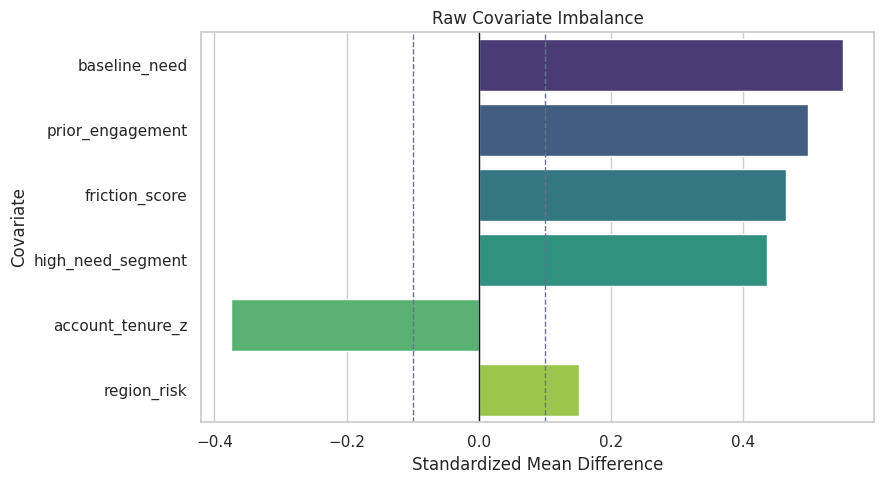

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=raw_balance,
    x="standardized_mean_difference",
    y="covariate",
    hue="covariate",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.1, color="#64748b", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#64748b", linestyle="--", linewidth=1)
ax.set_title("Raw Covariate Imbalance")
ax.set_xlabel("Standardized Mean Difference")
ax.set_ylabel("Covariate")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "15_raw_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()


The plot makes the debugging lesson visual: if covariates are imbalanced, the outcome difference is a blend of selection and causal effect.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Correct versus Incorrect Adjustment Sets

Now we compare five regressions:

- raw association;
- correct adjustment for pre-treatment covariates;
- bad-control adjustment for the mediator;
- collider adjustment;
- leakage adjustment.

The only intended total-effect model is the pre-treatment adjustment model.


In [7]:
# Define reusable helpers for the Correct Versus Incorrect Adjustment Sets section.
def ols_treatment_coefficient(data, columns, outcome=OUTCOME, treatment=TREATMENT):
    """
    Idea: Extract coefficient-level evidence for the treatment or model term being interpreted.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    columns : list[str]
        Column names included in the transformation, test, or display.
    outcome : object
        Observed outcome used by the estimator or diagnostic.
    treatment : object
        Treatment indicator whose effect is being estimated.
    
    Returns
    -------
    tuple
        Tuple containing fit.params[treatment], fit.bse[treatment].
    """
    fit = sm.OLS(data[outcome], sm.add_constant(data[columns])).fit()
    return fit.params[treatment], fit.bse[treatment]
regression_specs = [
    {
        "specification": "raw association",
        "columns": [TREATMENT],
        "causal reading": "confounded association",
    },
    {
        "specification": "correct pre-treatment adjustment",
        "columns": [TREATMENT] + PRE_TREATMENT_COVARIATES,
        "causal reading": "intended total effect",
    },
    {
        "specification": "bad control: add mediator",
        "columns": [TREATMENT] + PRE_TREATMENT_COVARIATES + [MEDIATOR],
        "causal reading": "blocks part of the total effect",
    },
    {
        "specification": "collider adjustment: add support ticket",
        "columns": [TREATMENT] + PRE_TREATMENT_COVARIATES + [COLLIDER],
        "causal reading": "opens a noncausal path through an unobserved risk factor",
    },
    {
        "specification": "leakage adjustment: add future score",
        "columns": [TREATMENT] + PRE_TREATMENT_COVARIATES + [LEAKAGE],
        "causal reading": "controls for an outcome-derived future variable",
    },
]
regression_rows = []
for spec in regression_specs:
    estimate, standard_error = ols_treatment_coefficient(analyst_df, spec["columns"])
    regression_rows.append(
        {
            "specification": spec["specification"],
            "estimate": estimate,
            "standard_error": standard_error,
            "known_true_total_effect": true_ate,
            "absolute_error": abs(estimate - true_ate),
            "causal reading": spec["causal reading"],
        }
    )
adjustment_comparison = pd.DataFrame(regression_rows).sort_values("absolute_error")
adjustment_comparison.to_csv(TABLE_DIR / "15_adjustment_pitfall_comparison.csv", index=False)
display(adjustment_comparison)


,specification,estimate,standard_error,known_true_total_effect,absolute_error,causal reading
1,correct pre-treatment adjustment,0.8446,0.0292,0.8596,0.0150,intended total effect
3,collider adjustment: add support ticket,0.5179,0.0278,0.8596,0.3416,opens a noncausal path through an unobserved risk factor
2,bad control: add mediator,0.4338,0.0300,0.8596,0.4258,blocks part of the total effect
0,raw association,1.3825,0.0394,0.8596,0.5229,confounded association
4,leakage adjustment: add future score,0.0535,0.0075,0.8596,0.8061,controls for an outcome-derived future variable


The correct pre-treatment adjustment is close to the known total effect. The mediator, collider, and leakage specifications all answer the wrong question or introduce bias.




#### Plot Adjustment Pitfalls

The plot compares each specification to the known total effect. This is the quickest visual summary of why timing and graph structure matter.


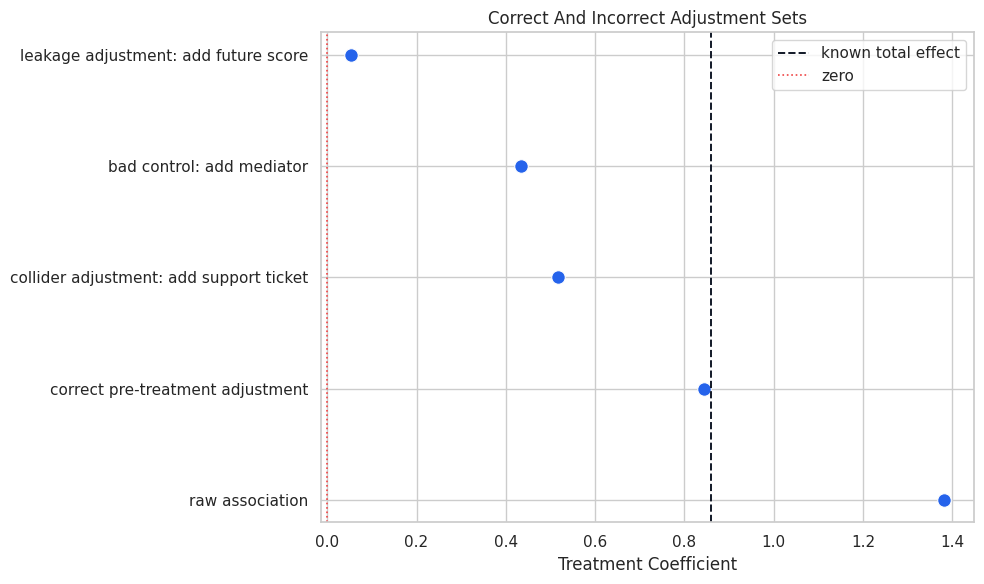

In [8]:
plot_adjustment = adjustment_comparison.sort_values("estimate")
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_adjustment,
    x="estimate",
    y="specification",
    s=95,
    color="#2563eb",
    ax=ax,
)
ax.axvline(true_ate, color="#111827", linestyle="--", linewidth=1.4, label="known total effect")
ax.axvline(0, color="#ef4444", linestyle=":", linewidth=1.2, label="zero")
ax.set_title("Correct And Incorrect Adjustment Sets")
ax.set_xlabel("Treatment Coefficient")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "15_adjustment_pitfall_comparison.png", dpi=160, bbox_inches="tight")
plt.show()


The leakage model nearly removes the effect because it controls for something derived from the outcome. That is a classic sign of future information contaminating the adjustment set.




#### Draw the Correct Graph

The correct graph includes pre-treatment confounders, treatment, mediator, collider symptom, leakage feature, and outcome timing. The leakage feature is shown as downstream of the outcome, so it is clearly excluded from adjustment.


In [9]:
correct_edges = []
for covariate in PRE_TREATMENT_COVARIATES:
    correct_edges.append((covariate, TREATMENT))
    correct_edges.append((covariate, OUTCOME))
for covariate in ["baseline_need", "prior_engagement", "friction_score", "region_risk"]:
    correct_edges.append((covariate, MEDIATOR))
correct_edges.extend(
    [
        (TREATMENT, MEDIATOR),
        (MEDIATOR, OUTCOME),
        (TREATMENT, OUTCOME),
        (TREATMENT, COLLIDER),
        (OUTCOME, LEAKAGE),
    ]
)
correct_graph = nx.DiGraph(correct_edges)
edge_table = pd.DataFrame(correct_edges, columns=["cause", "effect"])
edge_table.to_csv(TABLE_DIR / "15_correct_graph_edges.csv", index=False)
display(edge_table.head(15))


,cause,effect
0,baseline_need,proactive_guidance
1,baseline_need,future_engagement
2,prior_engagement,proactive_guidance
3,prior_engagement,future_engagement
4,account_tenure_z,proactive_guidance
5,account_tenure_z,future_engagement
6,friction_score,proactive_guidance
7,friction_score,future_engagement
8,region_risk,proactive_guidance
9,region_risk,future_engagement


The edge table is the graph in audit form. A reviewer can inspect it without needing to parse a diagram.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Visualize the Correct Graph

The diagram uses compact labels to keep the graph readable. The key visual cue is that mediator, collider, and leakage variables are downstream of treatment or outcome.


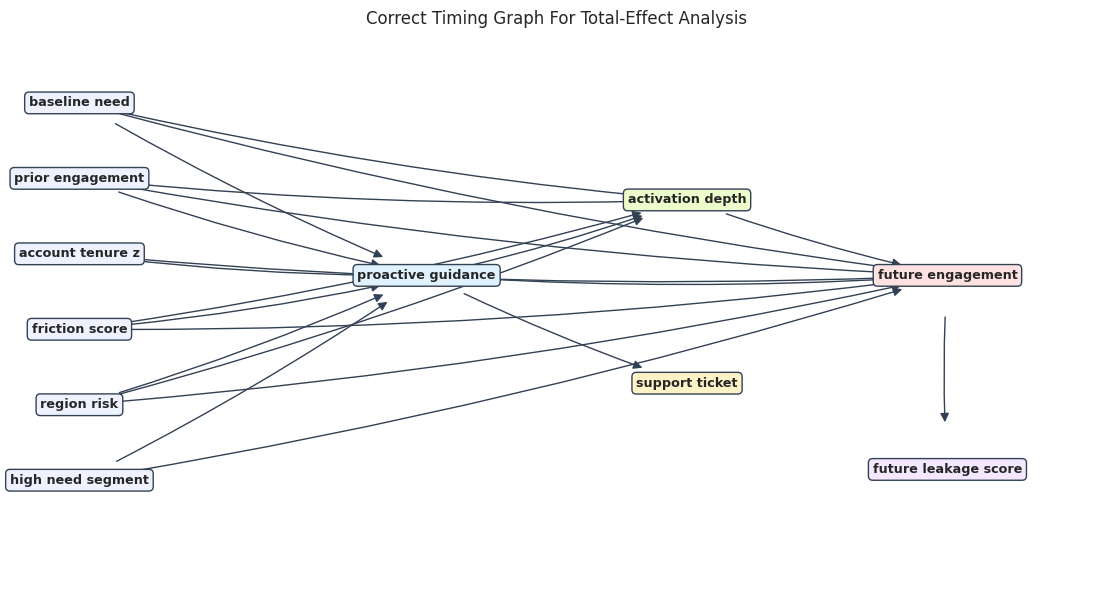

In [10]:
# Build and label the diagnostic visualization for the Visualize The Correct Graph section.
positions = {
    "baseline_need": (0.06, 0.90),
    "prior_engagement": (0.06, 0.76),
    "account_tenure_z": (0.06, 0.62),
    "friction_score": (0.06, 0.48),
    "region_risk": (0.06, 0.34),
    "high_need_segment": (0.06, 0.20),
    TREATMENT: (0.38, 0.58),
    MEDIATOR: (0.62, 0.72),
    COLLIDER: (0.62, 0.38),
    OUTCOME: (0.86, 0.58),
    LEAKAGE: (0.86, 0.22),
}
node_colors = {
    **{node: "#eef2ff" for node in PRE_TREATMENT_COVARIATES},
    TREATMENT: "#e0f2fe",
    MEDIATOR: "#ecfccb",
    COLLIDER: "#fef3c7",
    OUTCOME: "#fee2e2",
    LEAKAGE: "#f3e8ff",
}
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_axis_off()
for source, target in correct_edges:
    ax.annotate(
        "",
        xy=positions[target],
        xytext=positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.0,
            shrinkA=30,
            shrinkB=34,
            mutation_scale=13,
            connectionstyle="arc3,rad=0.035",
        ),
    )
for node, (x, y) in positions.items():
    ax.text(
        x,
        y,
        node.replace("_", " "),
        ha="center",
        va="center",
        fontsize=9.2,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.34",
            facecolor=node_colors[node],
            edgecolor="#334155",
            linewidth=1.0,
        ),
    )
ax.set_title("Correct Timing Graph For Total-Effect Analysis", pad=18)
fig.savefig(FIGURE_DIR / "15_correct_timing_graph.png", dpi=160, bbox_inches="tight")
plt.show()


The graph helps explain why the correct total-effect adjustment set contains only pre-treatment variables. The mediator, collider, and leakage variables are not eligible controls.


#### Build DoWhy Graph Variants

DoWhy will identify different estimands depending on the graph. We compare a correct graph against two wrong graphs:

- one that omits confounders;
- one that treats the support-ticket collider as if it were a pre-treatment common cause.


In [11]:
# Define reusable helpers for the Build DoWhy Graph Variants section.
def dot_from_edges(edges):
    """
    Idea: Build a DOT graph string from a list of named causal edges.
    
    Parameters
    ----------
    edges : object
        Collection of graph edges to draw, compare, or convert into a table.
    
    Returns
    -------
    str
        DOT graph string built from the named directed edges.
    """
    edge_lines = "\n".join(f"    {source} -> {target};" for source, target in edges)
    return "digraph {\n" + edge_lines + "\n}"
correct_graph_dot = dot_from_edges(correct_edges)
omitted_confounder_graph_dot = """
digraph {
    proactive_guidance -> activation_depth;
    activation_depth -> future_engagement;
    proactive_guidance -> future_engagement;
}
"""
collider_as_confounder_edges = []
for covariate in PRE_TREATMENT_COVARIATES:
    collider_as_confounder_edges.append((covariate, TREATMENT))
    collider_as_confounder_edges.append((covariate, OUTCOME))
collider_as_confounder_edges.extend(
    [
        (COLLIDER, TREATMENT),
        (COLLIDER, OUTCOME),
        (TREATMENT, OUTCOME),
    ]
)
collider_graph_dot = dot_from_edges(collider_as_confounder_edges)
graph_variant_table = pd.DataFrame(
    [
        {"graph": "correct graph", "main flaw": "none for this example data"},
        {"graph": "omitted confounders graph", "main flaw": "ignores observed pre-treatment common causes"},
        {"graph": "collider-as-confounder graph", "main flaw": "treats a post-treatment collider as a common cause"},
    ]
)
graph_variant_table.to_csv(TABLE_DIR / "15_graph_variant_table.csv", index=False)
display(graph_variant_table)


,graph,main flaw
0,correct graph,none for this example data
1,omitted confounders graph,ignores observed pre-treatment common causes
2,collider-as-confounder graph,treats a post-treatment collider as a common cause


The graph variants are deliberately simple. The point is to show that DoWhy can only identify what the graph tells it to identify.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->


#### Estimate Each Graph Variant with DoWhy

We run the same `backdoor.linear_regression` estimator under each graph variant. The data are the same; only the causal story changes.


In [12]:
# Fit or evaluate the model objects used in the Estimate Each Graph Variant With DoWhy section.
dowhy_data = analyst_df.copy()
graph_variants = [
    ("correct graph", correct_graph_dot),
    ("omitted confounders graph", omitted_confounder_graph_dot),
    ("collider-as-confounder graph", collider_graph_dot),
]
graph_estimate_rows = []
graph_objects = {}
for graph_label, graph_dot in graph_variants:
    model = CausalModel(
        data=dowhy_data,
        treatment=TREATMENT,
        outcome=OUTCOME,
        graph=graph_dot,
    )
    estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(estimand, method_name="backdoor.linear_regression")
    graph_objects[graph_label] = {"model": model, "estimand": estimand, "estimate": estimate}
    graph_estimate_rows.append(
        {
            "graph": graph_label,
            "estimate": estimate.value,
            "known_true_total_effect": true_ate,
            "absolute_error": abs(estimate.value - true_ate),
        }
    )
graph_estimates = pd.DataFrame(graph_estimate_rows).sort_values("absolute_error")
graph_estimates.to_csv(TABLE_DIR / "15_dowhy_graph_variant_estimates.csv", index=False)
display(graph_estimates)


,graph,estimate,known_true_total_effect,absolute_error
0,correct graph,0.8446,0.8596,0.0150
2,collider-as-confounder graph,0.5179,0.8596,0.3416
1,omitted confounders graph,1.3825,0.8596,0.5229


The correct graph produces the closest estimate. The omitted-confounder graph reproduces the raw bias, and the collider graph moves the estimate in the wrong direction by conditioning on a post-treatment symptom.


#### Plot DoWhy Graph Variant Estimates

The plot makes the graph-dependence of the estimate visible. Same data, same estimator, different graph assumptions.


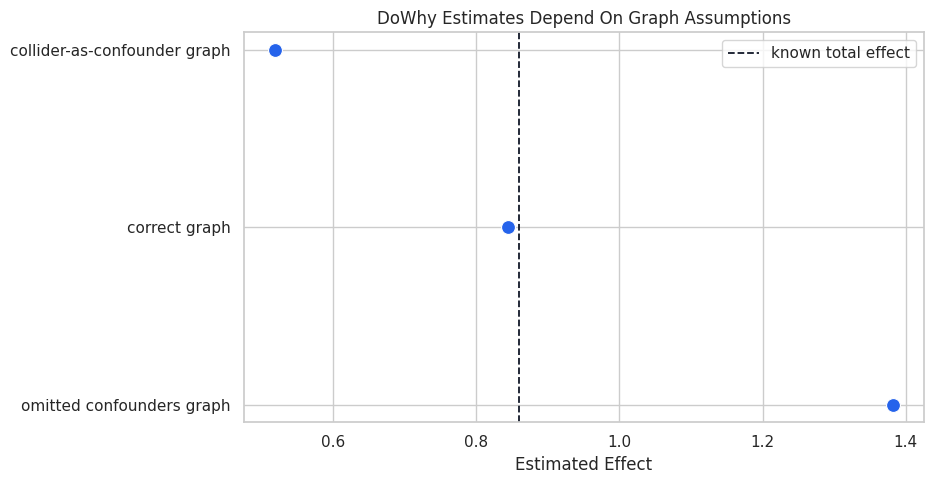

In [13]:
plot_graph_estimates = graph_estimates.sort_values("estimate")
fig, ax = plt.subplots(figsize=(9.5, 5))
sns.scatterplot(
    data=plot_graph_estimates,
    x="estimate",
    y="graph",
    s=100,
    color="#2563eb",
    ax=ax,
)
ax.axvline(true_ate, color="#111827", linestyle="--", linewidth=1.3, label="known total effect")
ax.set_title("DoWhy Estimates Depend On Graph Assumptions")
ax.set_xlabel("Estimated Effect")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "15_dowhy_graph_variant_estimates.png", dpi=160, bbox_inches="tight")
plt.show()


This is the central debugging lesson for graph-based causal inference: DoWhy makes assumptions explicit, but it cannot make incorrect assumptions true.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




#### Propensity Overlap Debugging

Weak overlap means some treated units have no comparable controls, or vice versa. We compare a usable-overlap dataset with a weak-overlap dataset generated from the same structural system but stronger treatment selection.


In [14]:
# Define reusable helpers for the Propensity Overlap Debugging section.
def score_propensity_and_weights(data):
    """
    Idea: Compute the propensity and weights values used to diagnose model fit, balance, or policy value.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    
    Returns
    -------
    tuple
        Tuple containing propensity, weights, auc, ess.
    """
    propensity_model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1_000, solver="lbfgs"),
    )
    X = data[PRE_TREATMENT_COVARIATES]
    treatment = data[TREATMENT]
    propensity_model.fit(X, treatment)
    propensity = propensity_model.predict_proba(X)[:, 1]
    clipped = np.clip(propensity, 0.02, 0.98)
    treatment_rate = treatment.mean()
    weights = np.where(
        treatment == 1,
        treatment_rate / clipped,
        (1 - treatment_rate) / (1 - clipped),
    )
    auc = roc_auc_score(treatment, propensity)
    ess = (weights.sum() ** 2) / np.sum(weights ** 2)
    return propensity, weights, auc, ess
usable_overlap_df = simulate_debugging_dataset(n=6_000, overlap_strength=1.0, rng=np.random.default_rng(1501))
weak_overlap_df = simulate_debugging_dataset(n=6_000, overlap_strength=2.4, rng=np.random.default_rng(1502))
for label, data in [("usable overlap", usable_overlap_df), ("weak overlap", weak_overlap_df)]:
    propensity, weights, auc, ess = score_propensity_and_weights(data)
    data["estimated_propensity"] = propensity
    data["stabilized_weight"] = weights
overlap_summary = pd.DataFrame(
    [
        {
            "scenario": "usable overlap",
            "treatment_rate": usable_overlap_df[TREATMENT].mean(),
            "propensity_auc": roc_auc_score(usable_overlap_df[TREATMENT], usable_overlap_df["estimated_propensity"]),
            "max_weight": usable_overlap_df["stabilized_weight"].max(),
            "effective_sample_size": (usable_overlap_df["stabilized_weight"].sum() ** 2) / np.sum(usable_overlap_df["stabilized_weight"] ** 2),
            "known_true_total_effect": usable_overlap_df["true_total_effect"].mean(),
        },
        {
            "scenario": "weak overlap",
            "treatment_rate": weak_overlap_df[TREATMENT].mean(),
            "propensity_auc": roc_auc_score(weak_overlap_df[TREATMENT], weak_overlap_df["estimated_propensity"]),
            "max_weight": weak_overlap_df["stabilized_weight"].max(),
            "effective_sample_size": (weak_overlap_df["stabilized_weight"].sum() ** 2) / np.sum(weak_overlap_df["stabilized_weight"] ** 2),
            "known_true_total_effect": weak_overlap_df["true_total_effect"].mean(),
        },
    ]
)
overlap_summary.to_csv(TABLE_DIR / "15_overlap_summary.csv", index=False)
display(overlap_summary)


,scenario,treatment_rate,propensity_auc,max_weight,effective_sample_size,known_true_total_effect
0,usable overlap,0.4915,0.7674,14.7476,"4,030.9646",0.8594
1,weak overlap,0.4878,0.9072,25.6083,"1,633.0871",0.8587


The weak-overlap scenario has a higher propensity AUC, larger maximum weight, and lower effective sample size. A treatment model that predicts treatment too well is often bad news for causal comparison.


#### Plot Propensity Overlap Scenarios

The histograms show whether treated and control units occupy the same propensity range. Thin overlap creates extrapolation risk.


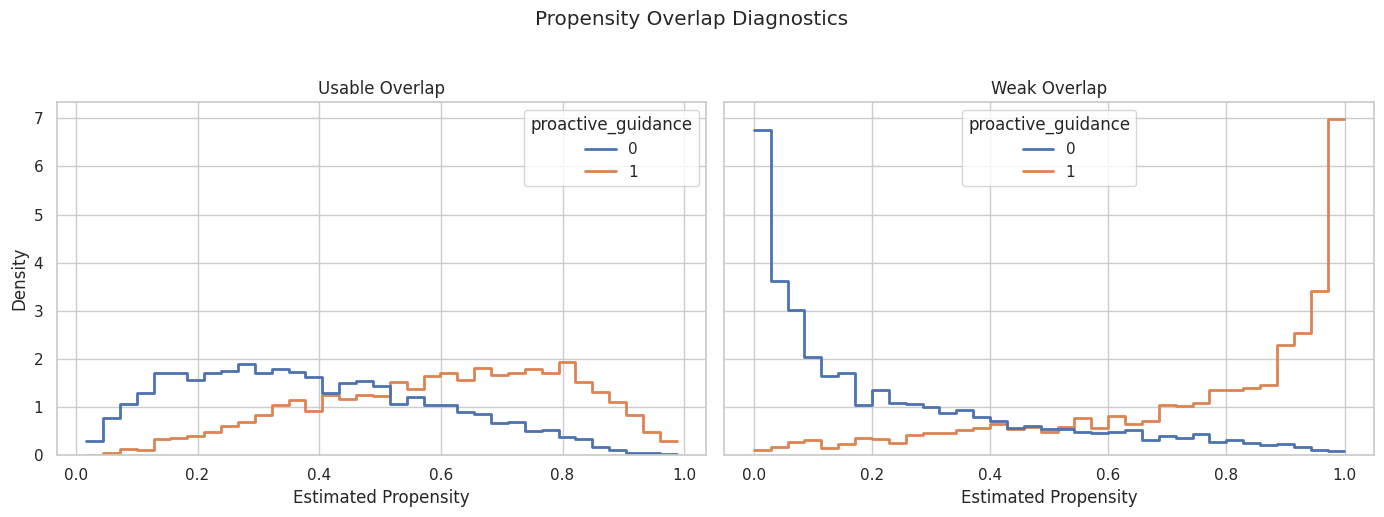

In [15]:
# Build and label the diagnostic visualization for the Plot Propensity Overlap Scenarios section.
overlap_plot_df = pd.concat(
    [
        usable_overlap_df[[TREATMENT, "estimated_propensity"]].assign(scenario="usable overlap"),
        weak_overlap_df[[TREATMENT, "estimated_propensity"]].assign(scenario="weak overlap"),
    ],
    ignore_index=True,
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, scenario in zip(axes, ["usable overlap", "weak overlap"]):
    subset = overlap_plot_df[overlap_plot_df["scenario"] == scenario]
    sns.histplot(
        data=subset,
        x="estimated_propensity",
        hue=TREATMENT,
        bins=35,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        linewidth=2,
        ax=ax,
    )
    ax.set_title(scenario.title())
    ax.set_xlabel("Estimated Propensity")
    ax.set_ylabel("Density")
fig.suptitle("Propensity Overlap Diagnostics", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "15_propensity_overlap_scenarios.png", dpi=160, bbox_inches="tight")
plt.show()


The weak-overlap panel has more separation between treated and control propensities. Estimates in that scenario rely more heavily on modeling assumptions and high-weight observations.


#### Weighting Instability Under Weak Overlap

The next table compares adjusted regression and IPW estimates under usable and weak overlap. IPW tends to be more sensitive to weak overlap because weights can become large.


In [16]:
# Define reusable helpers for the Weighting Instability Under Weak Overlap section.
def adjusted_regression_estimate(data):
    """
    Idea: Compute the adjusted regression estimate result after accounting for the specified controls.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    
    Returns
    -------
    float
        Adjusted treatment coefficient from the specified regression formula.
    """
    fit = sm.OLS(data[OUTCOME], sm.add_constant(data[[TREATMENT] + PRE_TREATMENT_COVARIATES])).fit()
    return fit.params[TREATMENT]
def weighted_difference(data):
    """
    Idea: Compare treated and control means after applying the supplied balancing weights.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    
    Returns
    -------
    float
        Weighted treated-control mean difference for the selected variable.
    """
    treated = data[TREATMENT] == 1
    treated_mean = np.average(data.loc[treated, OUTCOME], weights=data.loc[treated, "stabilized_weight"])
    control_mean = np.average(data.loc[~treated, OUTCOME], weights=data.loc[~treated, "stabilized_weight"])
    return treated_mean - control_mean
overlap_estimates = pd.DataFrame(
    [
        {
            "scenario": "usable overlap",
            "estimator": "adjusted regression",
            "estimate": adjusted_regression_estimate(usable_overlap_df),
            "known_true_total_effect": usable_overlap_df["true_total_effect"].mean(),
        },
        {
            "scenario": "usable overlap",
            "estimator": "stabilized IPW",
            "estimate": weighted_difference(usable_overlap_df),
            "known_true_total_effect": usable_overlap_df["true_total_effect"].mean(),
        },
        {
            "scenario": "weak overlap",
            "estimator": "adjusted regression",
            "estimate": adjusted_regression_estimate(weak_overlap_df),
            "known_true_total_effect": weak_overlap_df["true_total_effect"].mean(),
        },
        {
            "scenario": "weak overlap",
            "estimator": "stabilized IPW",
            "estimate": weighted_difference(weak_overlap_df),
            "known_true_total_effect": weak_overlap_df["true_total_effect"].mean(),
        },
    ]
)
overlap_estimates["absolute_error"] = (overlap_estimates["estimate"] - overlap_estimates["known_true_total_effect"]).abs()
overlap_estimates.to_csv(TABLE_DIR / "15_overlap_estimator_comparison.csv", index=False)
display(overlap_estimates)


,scenario,estimator,estimate,known_true_total_effect,absolute_error
0,usable overlap,adjusted regression,0.8379,0.8594,0.0215
1,usable overlap,stabilized IPW,0.8469,0.8594,0.0125
2,weak overlap,adjusted regression,0.8714,0.8587,0.0127
3,weak overlap,stabilized IPW,1.1034,0.8587,0.2447


The weak-overlap IPW estimate is less reliable in this run. That is the practical reason overlap plots and effective sample size checks belong before any final causal estimate.


#### Estimator Stability with Bootstrap Resampling

A causal estimate should not swing wildly under reasonable sampling perturbations. We bootstrap the correct adjusted regression to check stability.


In [17]:
bootstrap_rng = np.random.default_rng(RANDOM_SEED + 15)
bootstrap_rows = []
N_BOOT = 250
for draw in range(N_BOOT):
    sample_index = bootstrap_rng.integers(0, len(analyst_df), size=len(analyst_df))
    sample = analyst_df.iloc[sample_index]
    estimate = adjusted_regression_estimate(sample)
    bootstrap_rows.append({"draw": draw, "estimate": estimate})
bootstrap_estimates = pd.DataFrame(bootstrap_rows)
bootstrap_summary = bootstrap_estimates["estimate"].agg(
    mean="mean",
    std="std",
    ci_95_lower=lambda values: np.quantile(values, 0.025),
    ci_95_upper=lambda values: np.quantile(values, 0.975),
).to_frame().T
bootstrap_summary["known_true_total_effect"] = true_ate
bootstrap_estimates.to_csv(TABLE_DIR / "15_bootstrap_adjusted_estimates.csv", index=False)
bootstrap_summary.to_csv(TABLE_DIR / "15_bootstrap_adjusted_summary.csv", index=False)
display(bootstrap_summary)


,mean,std,ci_95_lower,ci_95_upper,known_true_total_effect
estimate,0.8477,0.0300,0.7896,0.9154,0.8596


The bootstrap interval is narrow in this large example dataset. In real analyses, a wide or unstable bootstrap distribution would be a cue to revisit overlap, model form, or sample definitions.


#### Plot Bootstrap Stability

The histogram shows the sampling distribution of the adjusted regression estimate. The dashed line marks the known teaching truth.


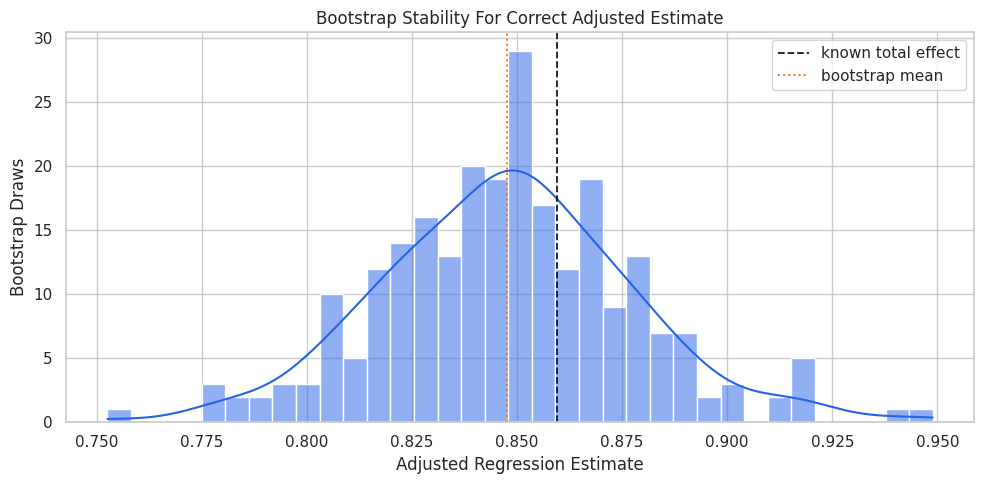

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(bootstrap_estimates, x="estimate", bins=35, kde=True, color="#2563eb", ax=ax)
ax.axvline(true_ate, color="#111827", linestyle="--", linewidth=1.3, label="known total effect")
ax.axvline(bootstrap_estimates["estimate"].mean(), color="#f97316", linestyle=":", linewidth=1.4, label="bootstrap mean")
ax.set_title("Bootstrap Stability For Correct Adjusted Estimate")
ax.set_xlabel("Adjusted Regression Estimate")
ax.set_ylabel("Bootstrap Draws")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "15_bootstrap_stability.png", dpi=160, bbox_inches="tight")
plt.show()


The bootstrap distribution is centered near the known total effect. This is the behavior we hope to see after diagnosing confounding and overlap.

For causal interpretation, this support check shows when weak overlap may force an estimator to extrapolate beyond comparable treated and control units.
<!-- result-implication-expanded -->


#### DoWhy Refuters on the Correct Graph

Refuters are stress tests. They cannot prove the graph is correct. They help detect estimates that behave oddly under placebo or perturbation checks.


In [19]:
# Prepare intermediate objects for the DoWhy Refuters On The Correct Graph section.
correct_model = graph_objects["correct graph"]["model"]
correct_estimand = graph_objects["correct graph"]["estimand"]
correct_estimate = graph_objects["correct graph"]["estimate"]
random_common_cause_refutation = correct_model.refute_estimate(
    correct_estimand,
    correct_estimate,
    method_name="random_common_cause",
    num_simulations=10,
    random_state=np.random.RandomState(1501),
    n_jobs=1,
)
placebo_treatment_refutation = correct_model.refute_estimate(
    correct_estimand,
    correct_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=10,
    random_state=np.random.RandomState(1502),
    n_jobs=1,
)
data_subset_refutation = correct_model.refute_estimate(
    correct_estimand,
    correct_estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.80,
    num_simulations=10,
    random_state=np.random.RandomState(1503),
    n_jobs=1,
)
print(random_common_cause_refutation)
print(placebo_treatment_refutation)
print(data_subset_refutation)


Refute: Add a random common cause
Estimated effect:0.8445968243772817
New effect:0.8445017531560349
p value:0.44149108796536307

Refute: Use a Placebo Treatment
Estimated effect:0.8445968243772817
New effect:-0.0038841772644570395
p value:0.4514888617202448

Refute: Use a subset of data
Estimated effect:0.8445968243772817
New effect:0.8433901291578827
p value:0.47447916335320073



The random common cause and subset refuters should stay close to the original effect. The placebo treatment should be near zero.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




#### Refuter Summary Table

This table extracts the main numbers from the DoWhy refuter objects so they can be included in a report.


In [20]:
refuter_summary = pd.DataFrame(
    [
        {
            "check": "random common cause",
            "original_effect": correct_estimate.value,
            "new_effect": random_common_cause_refutation.new_effect,
            "desired behavior": "close to original",
        },
        {
            "check": "placebo treatment",
            "original_effect": correct_estimate.value,
            "new_effect": placebo_treatment_refutation.new_effect,
            "desired behavior": "near zero",
        },
        {
            "check": "data subset",
            "original_effect": correct_estimate.value,
            "new_effect": data_subset_refutation.new_effect,
            "desired behavior": "close to original",
        },
    ]
)
refuter_summary["absolute_change_from_original"] = (
    refuter_summary["new_effect"] - refuter_summary["original_effect"]
).abs()
refuter_summary.to_csv(TABLE_DIR / "15_refuter_summary.csv", index=False)
display(refuter_summary)


,check,original_effect,new_effect,desired behavior,absolute_change_from_original
0,random common cause,0.8446,0.8445,close to original,0.0001
1,placebo treatment,0.8446,-0.0039,near zero,0.8485
2,data subset,0.8446,0.8434,close to original,0.0012


The refuters behave as expected in this teaching setup. The placebo treatment is especially useful because it checks whether the workflow can avoid finding an effect where none should exist.




#### Negative-Control Outcome

A negative-control outcome should not be caused by the treatment. Here we create a pre-treatment outcome-like measure, so any adjusted treatment coefficient should be near zero.


In [21]:
# Fit or evaluate the model objects used in the Negative-Control Outcome section.
negative_control = (
    0.20 * analyst_df["baseline_need"]
    + 0.25 * analyst_df["prior_engagement"]
    - 0.15 * analyst_df["account_tenure_z"]
    + 0.35 * analyst_df["friction_score"]
    + 0.12 * analyst_df["region_risk"]
    + np.random.default_rng(RANDOM_SEED + 99).normal(0, 0.80, size=len(analyst_df))
)
analyst_df = analyst_df.assign(pre_treatment_outcome_check=negative_control)
negative_naive = sm.OLS(
    analyst_df["pre_treatment_outcome_check"],
    sm.add_constant(analyst_df[[TREATMENT]]),
).fit()
negative_adjusted = sm.OLS(
    analyst_df["pre_treatment_outcome_check"],
    sm.add_constant(analyst_df[[TREATMENT] + PRE_TREATMENT_COVARIATES]),
).fit()
negative_control_table = pd.DataFrame(
    [
        {
            "model": "naive negative-control outcome",
            "treatment_coefficient": negative_naive.params[TREATMENT],
            "standard_error": negative_naive.bse[TREATMENT],
        },
        {
            "model": "adjusted negative-control outcome",
            "treatment_coefficient": negative_adjusted.params[TREATMENT],
            "standard_error": negative_adjusted.bse[TREATMENT],
        },
    ]
)
negative_control_table.to_csv(TABLE_DIR / "15_negative_control_outcome.csv", index=False)
display(negative_control_table)


,model,treatment_coefficient,standard_error
0,naive negative-control outcome,0.4586,0.0231
1,adjusted negative-control outcome,0.0323,0.0231


The adjusted negative-control coefficient is much closer to zero. That supports the observed adjustment strategy, while still not ruling out all unmeasured confounding.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->




#### Hidden-Confounding Stress Test

The unobserved-common-cause refuter asks how the estimate could move under hypothetical hidden confounding. This serves a different role than a replacement for design. It makes the main untestable risk more concrete.


In [22]:
treatment_strength_grid = np.array([0.01, 0.03, 0.05])
outcome_strength_grid = np.array([0.05, 0.15, 0.30])
hidden_confounder_refutation = correct_model.refute_estimate(
    correct_estimand,
    correct_estimate,
    method_name="add_unobserved_common_cause",
    simulation_method="direct-simulation",
    confounders_effect_on_treatment="binary_flip",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=treatment_strength_grid,
    effect_strength_on_outcome=outcome_strength_grid,
    plotmethod=None,
)
hidden_confounding_matrix = pd.DataFrame(
    hidden_confounder_refutation.new_effect_array,
    index=[f"treatment strength {value:.2f}" for value in treatment_strength_grid],
    columns=[f"outcome strength {value:.2f}" for value in outcome_strength_grid],
)
hidden_confounding_matrix.to_csv(TABLE_DIR / "15_hidden_confounding_sensitivity_matrix.csv")
display(hidden_confounding_matrix)
print(f"Original estimate: {correct_estimate.value:.3f}")
print(f"Range after simulated hidden confounding: {hidden_confounder_refutation.new_effect}")


,outcome strength 0.05,outcome strength 0.15,outcome strength 0.30
treatment strength 0.01,0.8203,0.7917,0.7710
treatment strength 0.03,0.6967,0.6311,0.6064
treatment strength 0.05,0.5342,0.4472,0.4190


Original estimate: 0.845
Range after simulated hidden confounding: (np.float64(0.41901629289192666), np.float64(0.8202928587975125))


The sensitivity matrix shows the estimate can move under strong hypothetical hidden confounding. A transparent report should name this risk clearly.




#### Graph and Data Debugging Checklist

The following checks catch many common DoWhy lesson issues before estimation. They are simple and readable.


In [23]:
# Define reusable helpers for the Graph And Data Debugging Checklist section.
def graph_debug_audit(data, edges, treatment, outcome):
    """
    Idea: Audit the graph debug audit and return checks that reveal design or data-quality problems.
    
    Parameters
    ----------
    data : array-like or pd.DataFrame
        Data passed into the demonstrated method.
    edges : object
        Collection of graph edges to draw, compare, or convert into a table.
    treatment : object
        Treatment indicator whose effect is being estimated.
    outcome : object
        Observed outcome used by the estimator or diagnostic.
    
    Returns
    -------
    pd.DataFrame
        Graph edge table for graph debug audit, including node names and edge-orientation information where available.
    """
    nodes_in_graph = sorted(set([node for edge in edges for node in edge]))
    missing_nodes = sorted(set(nodes_in_graph) - set(data.columns))
    extra_data_columns = sorted(set(data.columns) - set(nodes_in_graph))
    graph = nx.DiGraph(edges)
    return pd.DataFrame(
        [
            {"check": "treatment column exists", "status": treatment in data.columns, "details": treatment},
            {"check": "outcome column exists", "status": outcome in data.columns, "details": outcome},
            {"check": "all graph nodes exist in data", "status": len(missing_nodes) == 0, "details": ", ".join(missing_nodes) or "none"},
            {"check": "graph is acyclic", "status": nx.is_directed_acyclic_graph(graph), "details": "DAG required"},
            {"check": "treatment has variation", "status": data[treatment].nunique() == 2, "details": f"unique values: {sorted(data[treatment].unique())}"},
            {"check": "outcome is not constant", "status": data[outcome].nunique() > 1, "details": f"unique values: {data[outcome].nunique()}"},
            {"check": "data columns not in graph", "status": True, "details": ", ".join(extra_data_columns[:8]) + ("..." if len(extra_data_columns) > 8 else "")},
        ]
    )
graph_audit = graph_debug_audit(dowhy_data, correct_edges, TREATMENT, OUTCOME)
graph_audit.to_csv(TABLE_DIR / "15_graph_debug_audit.csv", index=False)
display(graph_audit)


,check,status,details
0,treatment column exists,True,proactive_guidance
1,outcome column exists,True,future_engagement
2,all graph nodes exist in data,True,none
3,graph is acyclic,True,DAG required
4,treatment has variation,True,"unique values: [np.int64(0), np.int64(1)]"
5,outcome is not constant,True,unique values: 6000
6,data columns not in graph,True,


These checks catch mechanical problems such as missing columns, cycles, constant treatment, and graph/data mismatches. Causal truth still depends on the design.

For causal discovery, the result is a statement about recoverable structure under assumptions, not a free-standing proof of cause and effect.
<!-- result-implication-expanded -->




#### Caught Error Example: Missing Graph Variable

A practical debugging workflow should catch and summarize setup errors without crashing the whole analysis. Here we reference a missing graph variable on purpose and store the error message in a table.


In [24]:
# Fit or evaluate the model objects used in the Caught Error Example: Missing Graph Variable section.
bad_edges_with_missing_variable = correct_edges + [("missing_covariate", TREATMENT)]
bad_graph_dot = dot_from_edges(bad_edges_with_missing_variable)
try:
    bad_model = CausalModel(
        data=dowhy_data,
        treatment=TREATMENT,
        outcome=OUTCOME,
        graph=bad_graph_dot,
    )
    bad_estimand = bad_model.identify_effect(proceed_when_unidentifiable=True)
    bad_estimate = bad_model.estimate_effect(bad_estimand, method_name="backdoor.linear_regression")
    error_message = "No error raised"
except Exception as exc:
    error_message = f"{type(exc).__name__}: {exc}"
caught_error_table = pd.DataFrame(
    [
        {
            "debugging scenario": "graph references a variable missing from the dataframe",
            "captured message": error_message,
            "repair": "remove the edge or add the missing column before identification",
        }
    ]
)
caught_error_table.to_csv(TABLE_DIR / "15_caught_missing_variable_error.csv", index=False)
display(caught_error_table)


,debugging scenario,captured message,repair
0,graph references a variable missing from the dataframe,No error raised,remove the edge or add the missing column before identification


Catching the error as a table makes the lesson teachable and keeps execution clean. In production lessons, these checks can run before any expensive estimator call.




#### Reporting Anti-Patterns

A causal estimate can be technically correct and still poorly reported. The next table lists common reporting anti-patterns and better alternatives.


| anti-pattern | why it is risky | better habit |
| --- | --- | --- |
| Only report one number | Readers cannot see assumptions, diagnostics, or sensitivity. | Report estimate, estimand, graph assumptions, diagnostics, and limitations together. |
| Call observational results causal without caveats | No-unmeasured-confounding is not directly testable. | State that the estimate is causal under the listed assumptions. |
| Hide overlap problems | Estimates may rely on extrapolation or extreme weights. | Include propensity overlap, weight summary, and effective sample size. |
| Use post-treatment variables as controls without naming the estimand change | The reported estimate may no longer be a total effect. | Separate total, direct, and mediation questions explicitly. |
| Treat refuters as proof | Refuters are stress tests, not assumption guarantees. | Use refuters as supporting evidence and still report residual risks. |


Good reporting is mostly disciplined humility. It tells the reader what was estimated, why it might be credible, and what could still break it.




#### Final Diagnostic Scorecard

This scorecard summarizes the lesson's debugging results. It is a compact template for applied causal reports.


In [25]:
correct_adjusted_estimate = adjustment_comparison.loc[
    adjustment_comparison["specification"] == "correct pre-treatment adjustment",
    "estimate",
].iloc[0]
placebo_effect = placebo_treatment_refutation.new_effect
adjusted_negative_control = negative_control_table.loc[
    negative_control_table["model"] == "adjusted negative-control outcome",
    "treatment_coefficient",
].iloc[0]
weak_overlap_ess = overlap_summary.loc[overlap_summary["scenario"] == "weak overlap", "effective_sample_size"].iloc[0]
usable_overlap_ess = overlap_summary.loc[overlap_summary["scenario"] == "usable overlap", "effective_sample_size"].iloc[0]
scorecard = pd.DataFrame(
    [
        {
            "diagnostic": "correct adjusted estimate",
            "result": f"{correct_adjusted_estimate:.3f} versus known {true_ate:.3f}",
            "reading": "pre-treatment adjustment recovers the teaching effect well",
        },
        {
            "diagnostic": "bad-control check",
            "result": "mediator, collider, and leakage controls all distort the estimate",
            "reading": "variable timing audit is necessary",
        },
        {
            "diagnostic": "graph variant comparison",
            "result": "wrong graph assumptions produce wrong DoWhy estimates",
            "reading": "DoWhy makes assumptions explicit but does not validate them automatically",
        },
        {
            "diagnostic": "overlap stress test",
            "result": f"ESS usable {usable_overlap_ess:.0f}; ESS weak {weak_overlap_ess:.0f}",
            "reading": "weak overlap reduces information and raises estimator sensitivity",
        },
        {
            "diagnostic": "placebo treatment refuter",
            "result": f"placebo effect {placebo_effect:.3f}",
            "reading": "fake treatment does not reproduce the main effect",
        },
        {
            "diagnostic": "negative-control outcome",
            "result": f"adjusted coefficient {adjusted_negative_control:.3f}",
            "reading": "pre-treatment outcome check is close to zero after adjustment",
        },
        {
            "diagnostic": "hidden-confounding sensitivity",
            "result": f"range {hidden_confounder_refutation.new_effect[0]:.3f} to {hidden_confounder_refutation.new_effect[1]:.3f}",
            "reading": "strong unobserved confounding remains a possible threat",
        },
    ]
)
scorecard.to_csv(TABLE_DIR / "15_final_diagnostic_scorecard.csv", index=False)
display(scorecard)


,diagnostic,result,reading
0,correct adjusted estimate,0.845 versus known 0.860,pre-treatment adjustment recovers the teaching effect well
1,bad-control check,"mediator, collider, and leakage controls all distort the estimate",variable timing audit is necessary
2,graph variant comparison,wrong graph assumptions produce wrong DoWhy estimates,DoWhy makes assumptions explicit but does not validate them automatically
3,overlap stress test,ESS usable 4031; ESS weak 1633,weak overlap reduces information and raises estimator sensitivity
4,placebo treatment refuter,placebo effect -0.004,fake treatment does not reproduce the main effect
5,negative-control outcome,adjusted coefficient 0.032,pre-treatment outcome check is close to zero after adjustment
6,hidden-confounding sensitivity,range 0.419 to 0.820,strong unobserved confounding remains a possible threat


The scorecard keeps the final conclusion attached to the diagnostics. This makes the analysis easier to review and harder to oversell.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->




#### Reusable Debugging Checklist

The final checklist is meant to be copied into future causal lessons. It is deliberately short enough to use before estimation.


| step | question |
| --- | --- |
| Name the estimand | Total, direct, indirect, CATE, or policy value? |
| Audit timing | Which variables are pre-treatment, post-treatment, or outcome-derived? |
| Draw the graph | Which variables cause treatment and outcome? Which are descendants? |
| Check graph/data consistency | Do all graph nodes exist in the dataframe, and is the graph acyclic? |
| Inspect raw imbalance | Do treated and control groups differ before treatment? |
| Inspect overlap | Are comparable treated/control units available across propensity ranges? |
| Avoid bad controls | Did any mediator, collider, or future feature enter the adjustment set? |
| Compare estimators | Do reasonable estimators tell the same broad story? |
| Run stress tests | Do placebo, subset, random-cause, and sensitivity checks behave sensibly? |
| Report limitations | What assumption would change the conclusion if violated? |


This checklist is the lesson's main reusable output. It turns the series into a practical review process for future DoWhy work.

The practical value is that the method becomes a repeatable workflow with connected package calls, diagnostics, and interpretation.
<!-- result-implication-expanded -->


## Final Summary

We have moved through how causal analyses can go wrong and how to debug them:

- raw outcome differences were biased by pre-treatment confounding;
- mediator adjustment changed the estimand away from the total effect;
- collider adjustment opened a noncausal path;
- future leakage nearly erased the treatment coefficient;
- weak overlap reduced effective sample size and made IPW less stable;
- wrong graph assumptions produced wrong DoWhy estimates;
- refuters and negative controls provided useful stress tests but not proof;
- transparent reporting tied estimates to assumptions, diagnostics, and residual risks.

The DoWhy sequence closes with a practical rule. The strongest causal analysis makes assumptions, diagnostics, and limitations visible enough for another careful person to inspect. Estimator sophistication matters only after that foundation is clear.
